In [2]:

import torch
print("GPU Available:", torch.cuda.is_available())


GPU Available: True


In [3]:
!pip install librosa

In [4]:
import kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.


In [5]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/ravdess-emotional-speech-audio
['Actor_02', 'Actor_17', 'Actor_05', 'Actor_16', 'Actor_21', 'Actor_01', 'Actor_11', 'Actor_20', 'Actor_08', 'Actor_15', 'Actor_06', 'Actor_12', 'Actor_23', 'Actor_24', 'Actor_22', 'Actor_04', 'Actor_19', 'Actor_10', 'Actor_09', 'audio_speech_actors_01-24', 'Actor_14', 'Actor_03', 'Actor_13', 'Actor_18', 'Actor_07']


In [6]:
import os

sample_folder = os.path.join(path, "Actor_01")
print(os.listdir(sample_folder)[:5])

['03-01-02-01-02-02-01.wav', '03-01-01-01-01-02-01.wav', '03-01-04-02-01-02-01.wav', '03-01-02-02-02-01-01.wav', '03-01-02-01-02-01-01.wav']


In [7]:
import librosa
import numpy as np

def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)

    # MFCC (most important feature)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)

    return mfcc

In [8]:
sample_file = os.path.join(path, "Actor_01", os.listdir(sample_folder)[0])

features = extract_features(sample_file)

print(features.shape)

(40,)


In [9]:
def load_data(data_path):
    X, y = [], []

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)

                features = extract_features(file_path)
                X.append(features)

                # emotion label from filename
                label = int(file.split("-")[2])
                y.append(label)

    return np.array(X), np.array(y)

In [10]:
X, y = load_data(path)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2880, 40)
y shape: (2880,)


In [11]:
import torch
import torch.nn as nn

class SpeechModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [12]:
input_size = X.shape[1]
num_classes = len(set(y))

model = SpeechModel(input_size, num_classes)

print(model)


SpeechModel(
  (fc1): Linear(in_features=40, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=8, bias=True)
)


In [14]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

# FIX labels (important)
y = y - 1

# convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# dataset + loader
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_list = []

# training loop
for epoch in range(10):
    total_loss = 0

    for xb, yb in loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_list.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 218.3595
Epoch 2, Loss: 171.3192
Epoch 3, Loss: 160.3224
Epoch 4, Loss: 151.9986
Epoch 5, Loss: 144.0112
Epoch 6, Loss: 143.8752
Epoch 7, Loss: 141.0955
Epoch 8, Loss: 138.1470
Epoch 9, Loss: 131.2965
Epoch 10, Loss: 127.8989


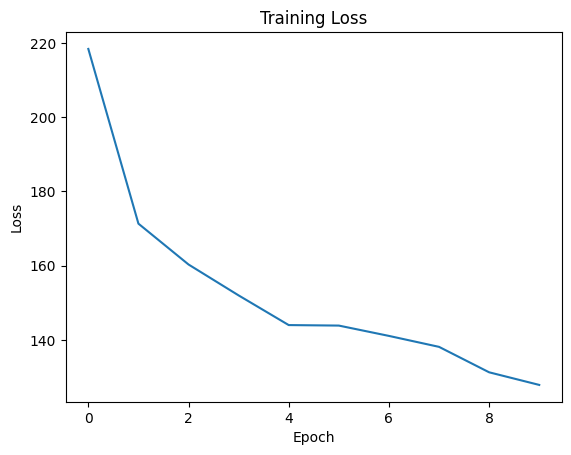

In [15]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [16]:
model.eval()

test_file = "test.wav"

features = extract_features(test_file)
features = torch.tensor(features, dtype=torch.float32).unsqueeze(0)

output = model(features)
prediction = torch.argmax(output, dim=1)

print("Predicted emotion class:", prediction.item())

/tmp/ipykernel_1211/4221086760.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=3, offset=0.5)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'test.wav'

In [17]:
import os
import torch

# show files available
print("Files in current folder:", os.listdir())

# 👉 change this name if needed
test_file = "test.wav"

# check if file exists
if not os.path.exists(test_file):
    print("❌ File not found. Rename your file to 'test.wav' or update the filename.")
else:
    print("✅ File found, running prediction...")

    model.eval()

    features = extract_features(test_file)
    features = torch.tensor(features, dtype=torch.float32).unsqueeze(0)

    output = model(features)
    prediction = torch.argmax(output, dim=1)

    print("🎯 Predicted emotion class:", prediction.item())

Files in current folder: ['.config', 'sample_data']
❌ File not found. Rename your file to 'test.wav' or update the filename.


In [18]:
import os
print(os.listdir())

['.config', '03-01-05-01-02-02-01.wav', 'sample_data']


In [19]:
test_file = "03-01-05-01-02-02-01.wav"

model.eval()

features = extract_features(test_file)
features = torch.tensor(features, dtype=torch.float32).unsqueeze(0)

output = model(features)
prediction = torch.argmax(output, dim=1)

print("🎯 Predicted emotion class:", prediction.item())

🎯 Predicted emotion class: 4


In [20]:
torch.save(model.state_dict(), "/content/drive/MyDrive/model.pth")

RuntimeError: Parent directory /content/drive/MyDrive does not exist.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
import torch
torch.save(model.state_dict(), "/content/drive/MyDrive/model.pth")